In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df_clean = pd.read_csv("processed_data/NVDA_cleaned_data.csv")

df_clean['Close'] = pd.to_numeric(df_clean['Close'], errors='coerce')
df_clean['Volume'] = pd.to_numeric(df_clean['Volume'], errors='coerce')
df_clean.dropna(subset=['Close'], inplace=True)

In [2]:
print(df_clean.describe())
print(df_clean.info())

            Close        Volume
count  557.000000  5.570000e+02
mean   136.061669  2.876111e+08
std     38.297762  1.507291e+08
min     47.539940  6.552850e+07
25%    110.683914  1.772136e+08
50%    134.655869  2.355189e+08
75%    176.950562  3.637090e+08
max    207.017273  1.142269e+09
<class 'pandas.core.frame.DataFrame'>
Index: 557 entries, 2 to 558
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   557 non-null    object 
 1   Close   557 non-null    float64
 2   High    557 non-null    object 
 3   Low     557 non-null    object 
 4   Open    557 non-null    object 
 5   Volume  557 non-null    float64
dtypes: float64(2), object(4)
memory usage: 30.5+ KB
None


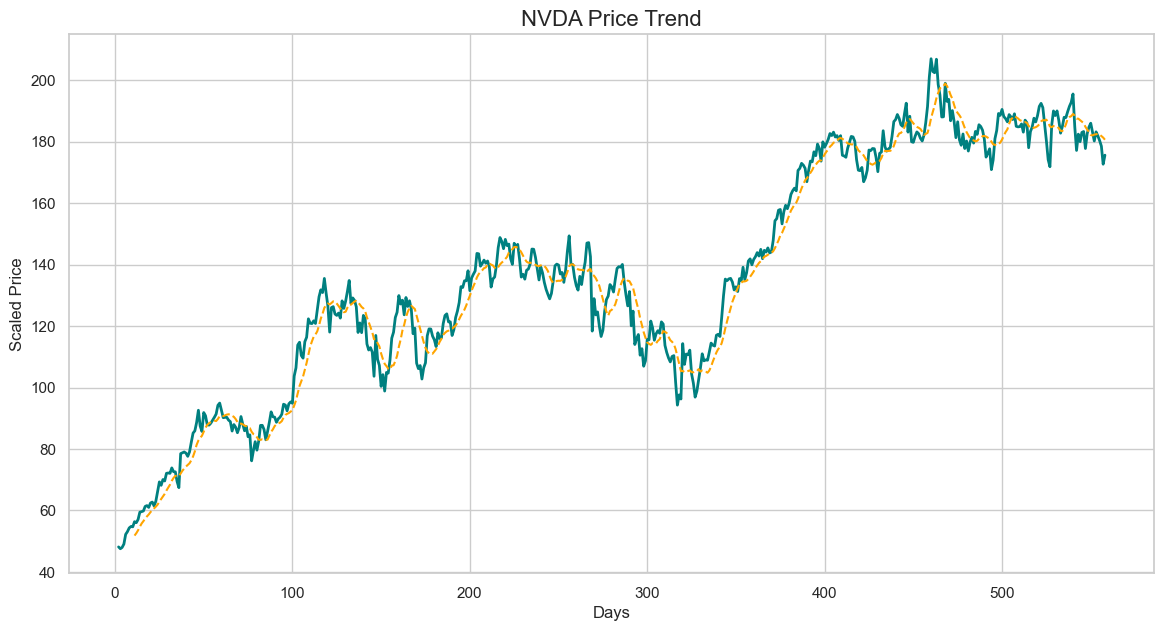

In [3]:
plt.figure(figsize=(14, 7))
plt.plot(df_clean.index, df_clean['Close'], color='teal', linewidth=2)

df_clean['Rolling_Mean'] = df_clean['Close'].rolling(window=10).mean()
plt.plot(df_clean.index, df_clean['Rolling_Mean'], color='orange', linestyle='--')

plt.title('NVDA Price Trend', fontsize=16)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Scaled Price', fontsize=12)
plt.show()

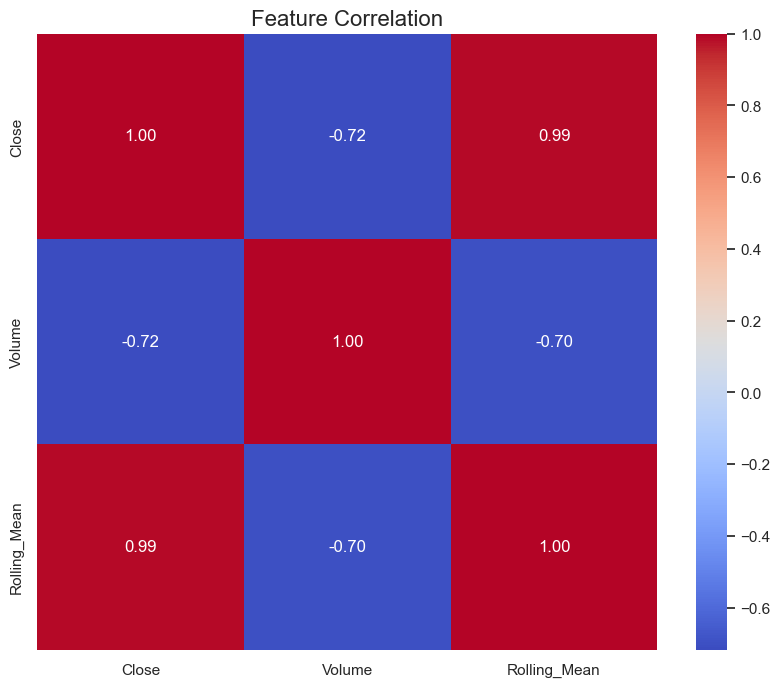

In [4]:
plt.figure(figsize=(10, 8))
numeric_only = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_only.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation', fontsize=16)
plt.show()

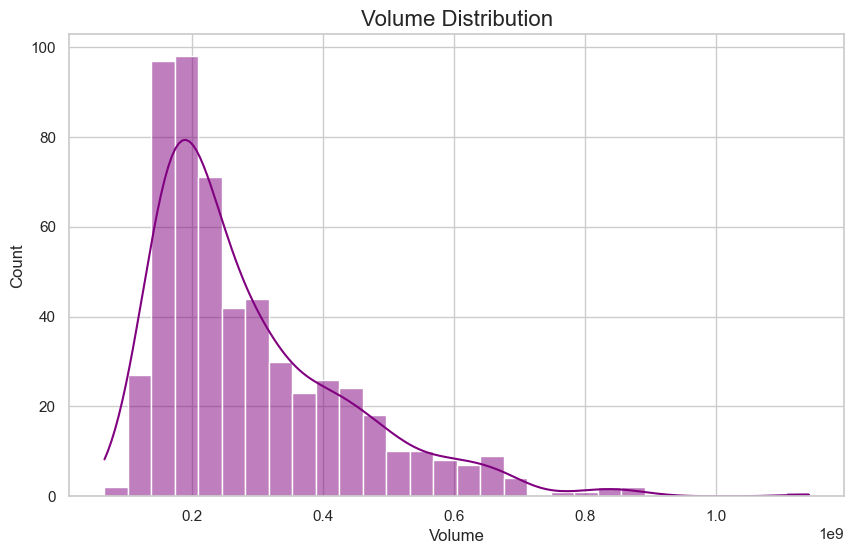

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Volume'], kde=True, color='purple', bins=30)
plt.title('Volume Distribution', fontsize=16)
plt.show()